# Two-tower recommendations

## Introduction

Imagine a film platform with millions of users. Every day, new films come out, and new users sign up.

A classic way to recommend is to use the likes of the other users: find the users who liked the same films as you, your **nearest neighbors**, and recommend what they liked. It works well, but not on this platform:
- it compares every user with every other user. With millions of users, this table fits nowhere,
- the **newcomers**: a new film or a new user has no likes, so no neighbor.

Yet we know more than the likes: the genres of a new film, the age of a new user. Can one single model learn from the likes, and use all this too?

That is the idea of the **two-tower** model: *describe every user with a short vector, describe every film with a short vector, and learn them so that each user's vector points toward the films they like.*

![A user tower turns what we know about a user into a vector, a film tower does the same for a film, and the dot product of the two vectors gives the score.](images/two_towers.svg)

Each side has its own small neural network, called a **tower**. The user tower turns what we know about a user into a vector. The film tower does the same for a film. The score of a film for a user is the **dot product** of their two vectors: it is high when the two vectors point the same way.

We could choose these vectors ourselves, for example the genres of a film (chapter 2 does that). Here, the model learns them.

## Example scenario

We use **MovieLens 100K**, a classic dataset from the [GroupLens research group](https://grouplens.org/datasets/movielens/100k/): 943 users gave 100,000 ratings, from 1 to 5, to 1,682 films. A small `movielens` module downloads it and reads the files. First, the films and the ratings:

In [1]:
from recommendationsystems.movielens import load_movies, load_ratings

genre_names, titles, genres = load_movies()
ratings = load_ratings()
print(ratings[:5])

[[259 254   4]
 [259 285   4]
 [259 297   4]
 [259 184   4]
 [259 172   4]]


Each row is one rating: a user, a film, and a rating from 1 to 5, sorted by time. A rating of 4 or 5 means that the user **liked** the film.

We follow one user through the chapter, user 366. Among the films they liked: Psycho, The Birds, Scream, Evil Dead II, Braindead... A horror fan! Keep them in mind, we will check what each recommender suggests to them.

To know if a recommender is good, we cannot ask the real users. So we **hide the last 10 ratings** of each user, as if they had not happened yet. The recommender only sees the rest, the **history**, and suggests 10 films. Then we reveal the hidden ratings: if at least one of the 10 films was liked later, it is a **hit**!

In [2]:
import numpy as np
from recommendationsystems.movielens import MovieId, UserId

fan = 366
history = {}  # key: user, value: array of (film, rating) the recommender can see
liked_later = {}  # key: user, value: set of hidden films the user liked
for user in np.unique(ratings[:, 0]):
    user_ratings = ratings[ratings[:, 0] == user]
    history[user] = user_ratings[:-10, 1:]
    liked_later[user] = {movie for movie, rating in user_ratings[-10:, 1:] if rating >= 4}

def liked(user: UserId) -> np.ndarray:
    return history[user][history[user][:, 1] >= 4, 0]

Every recommender works the same way: it gives **a score to every film**, and we keep the 10 films with the best score, skipping the films the user has already seen. We test it on every user who liked at least one film before and after the cut. The **hit rate** is the share of these users who got a hit.

In [3]:
from collections.abc import Callable

def top_10(scores: np.ndarray, user: UserId) -> list[MovieId]:
    """Return the 10 best-scored films that the user has not seen yet."""
    seen = set(history[user][:, 0])
    best_first = np.argsort(-scores, kind="stable")  # all films, best score first
    return [int(movie) for movie in best_first if movie not in seen][:10]

test_users = [user for user in history if liked_later[user] and len(liked(user))]

def evaluate(reco: Callable[[UserId], list[MovieId]]) -> float:
    hits = [bool(set(reco(user)) & liked_later[user]) for user in test_users]
    return sum(hits) / len(hits)

Two reference points: random films, and popular films (the films with the most likes, the same list for everybody):

In [4]:
rng = np.random.default_rng(21)

def random_reco(user: UserId) -> list[MovieId]:
    return top_10(rng.random(len(titles)), user)

likes = np.bincount(np.concatenate([liked(user) for user in history]), minlength=len(titles))

def popular_reco(user: UserId) -> list[MovieId]:
    return top_10(likes, user)

print(f"Random: {evaluate(random_reco):.3f}")
print(f"Popular: {evaluate(popular_reco):.3f}")

Random: 0.034
Popular: 0.346


The score to beat is 0.518 for the **nearest neighbors** (chapter 3): find the 40 users whose likes are closest to yours, and recommend what they liked.

## One vector per user, one vector per film

### a. Let's start with the simplest towers

Let's start with towers that know nothing about a user or a film, except its number.

A number is not a vector, but we can turn it into one: a **one-hot** vector. It is full of 0s, with a single 1 at the position of the user.

The tower is a single layer: it multiplies this vector by a table of weights. With a single 1, the multiplication simply picks one row of the table: the vector of this user!

![User 2 as a one-hot vector: multiplied by the table of weights, the single 1 picks the third row, which becomes the vector of user 2.](images/one_hot_lookup.svg)

So this first tower is nothing more than a table, with one vector of 32 numbers per user. Same thing for the films.

In code, a layer that multiplies by a table of weights is an `nn.Linear` from PyTorch. The model takes the features of the users and of the films, and gives the score of every film for each user:

In [5]:
import torch
from torch import nn

class TwoTowers(nn.Module):
    def __init__(self, user_features: np.ndarray, film_features: np.ndarray, size: int = 32):
        super().__init__()
        self.user_features = torch.tensor(user_features, dtype=torch.float32)
        self.film_features = torch.tensor(film_features, dtype=torch.float32)
        self.user_tower = nn.Linear(self.user_features.shape[1], size, bias=False)
        self.film_tower = nn.Linear(self.film_features.shape[1], size, bias=False)

    def user_vectors(self, users: torch.Tensor) -> torch.Tensor:
        return self.user_tower(self.user_features[users])

    def film_vectors(self) -> torch.Tensor:
        return self.film_tower(self.film_features)

    def forward(self, users: torch.Tensor) -> torch.Tensor:
        """Return the score of every film for each user."""
        return self.user_vectors(users) @ self.film_vectors().T

Our first model uses the one-hot vectors as features. `np.eye` builds all of them at once: row `i` has a single 1, at position `i`.

In [6]:
n_users = ratings[:, 0].max() + 1  # user ids start at 1, so row 0 stays empty

torch.manual_seed(21)
ids_model = TwoTowers(np.eye(n_users), np.eye(len(titles)))

### b. Let's train it

At first, the vectors are random. To learn them, we use every like of the histories: a user, and a film they liked.

For each like, we ask the model a question: *among the 1,682 films, which one did this user like?* The model scores every film, and the **softmax** turns the scores into probabilities. The loss is the **cross-entropy**: it is small when the liked film gets a high probability.

$$
\text{loss} = -\log \frac{e^{\,\text{score}(\text{user}, \text{liked film})}}{\sum_{\text{film}} e^{\,\text{score}(\text{user}, \text{film})}}
$$

At each step, the optimizer nudges the vectors to reduce the loss: the vector of the user moves toward the vector of the liked film, and away from the others.

In [7]:
liked_pairs = torch.tensor([(user, movie) for user in history for movie in liked(user)])

def train(model: TwoTowers, epochs: int = 10) -> list[float]:
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []
    for _ in range(epochs):  # an epoch is one pass over all the likes
        for batch in liked_pairs[torch.randperm(len(liked_pairs))].split(512):
            users, films = batch.T
            loss = nn.functional.cross_entropy(model(users), films)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
    return losses

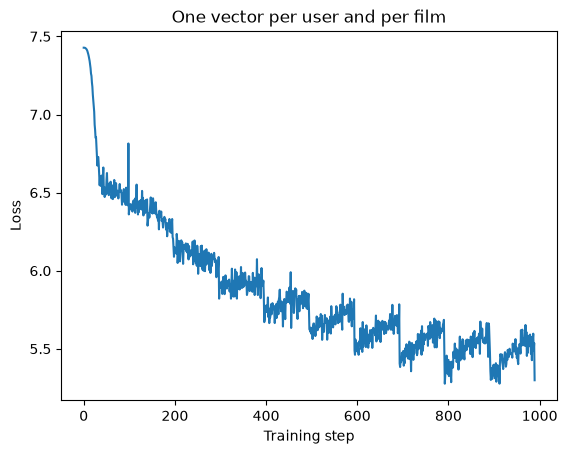

In [8]:
import matplotlib.pyplot as plt

losses = train(ids_model)

plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("One vector per user and per film")
plt.show()

The loss starts around 7.4, that is $\log(1682)$: the model guesses at random among 1,682 films. Then it goes down: the model gets better and better at guessing the liked films.

### c. Let's recommend

The scores of a user are one row of the output of the model:

In [9]:
def scores(model: TwoTowers, user: UserId) -> np.ndarray:
    with torch.no_grad():
        return model(torch.tensor([user]))[0].numpy()

def ids_reco(user: UserId) -> list[MovieId]:
    return top_10(scores(ids_model, user), user)

for movie in ids_reco(fan):
    print(titles[movie])

Interview with the Vampire (1994)
Shining, The (1980)
Alien (1979)
Aliens (1986)
In the Mouth of Madness (1995)
Wes Craven's New Nightmare (1994)
Amityville Horror, The (1979)
Body Snatchers (1993)
Candyman (1992)
Howling, The (1981)


Horror everywhere: The Shining, Alien, Candyman... And The Shining is one of the films our fan liked later: a hit! Yet the model has never seen a single genre.

### d. How does this recommender perform?

In [10]:
print(f"Two towers, IDs only: {evaluate(ids_reco):.3f}")

Two towers, IDs only: 0.513


Almost as good as the 40 nearest neighbors (0.518)!

And it is much smaller. The neighbors needed 943 × 943 = 889,249 similarities. Our towers only need 32 numbers per user and per film:

In [11]:
n_numbers = sum(parameter.numel() for parameter in ids_model.parameters())
print(f"Numbers in the towers: {n_numbers:,}")

Numbers in the towers: 84,032


Ten times less, and the gap grows with the platform. With a million users, the neighbors would need a thousand billion similarities, and the user tower 32 million numbers.

### e. What did the vectors learn?

We never told the model anything about the films, only who liked what. Yet films with the same audience should end up with similar vectors. Let's check with the **cosine similarity**, which measures the angle between two vectors: 1 when they point the same way, 0 when they have nothing in common:

In [12]:
with torch.no_grad():
    film_vectors = ids_model.film_vectors().numpy()
unit_vectors = film_vectors / np.linalg.norm(film_vectors, axis=1, keepdims=True)

for title in ["Psycho (1960)", "Evil Dead II (1987)"]:
    movie = titles.index(title)
    closest = np.argsort(-(unit_vectors @ unit_vectors[movie]), kind="stable")[1:4]  # skip the film itself
    print(f"{title} -> {[titles[similar] for similar in closest]}")

Psycho (1960) -> ['Jaws (1975)', 'Silence of the Lambs, The (1991)', 'Alien (1979)']
Evil Dead II (1987) -> ['Army of Darkness (1993)', 'From Dusk Till Dawn (1996)', 'Nightmare on Elm Street, A (1984)']


Evil Dead II gives its sequel, Army of Darkness. Psycho gives other thrillers and horror films. The vectors found the genres from the likes alone.

## The weak spot: newcomers, again

Now, imagine a new horror comedy is released today. What is its vector? Its number was not there during training, so it has no row in the table. The same goes for a new user. We are stuck again.

But we know more than a number about them! A new film comes with its genres. A new user fills in a form when they sign up. Let's give all this to the towers.

## Two towers: vectors from what we know

### a. Let's describe the films

The film tower now receives the one-hot vector of the film, followed by its genres. The number lets the tower learn what is special about each film. The genres let it say something about a film it has never seen.

In [13]:
film_features = np.hstack([np.eye(len(titles)), genres])
print(f"Film features: {film_features.shape[1]} numbers per film")

Film features: 1701 numbers per film


### b. Let's describe the users

For the users, MovieLens gives us their age, gender and occupation:

In [14]:
from recommendationsystems.movielens import load_users

users = load_users()
occupations = sorted({occupation for _, _, occupation in users.values()})

print(users[fan])
print(occupations)

(20, 'F', 'student')
['administrator', 'artist', 'doctor', 'educator', 'engineer', 'entertainment', 'executive', 'healthcare', 'homemaker', 'lawyer', 'librarian', 'marketing', 'none', 'other', 'programmer', 'retired', 'salesman', 'scientist', 'student', 'technician', 'writer']


Like the genres of a film, we turn this into a row of numbers: the age divided by 100, a 1 in the gender cell, and a 1 in the occupation cell.

In [15]:
def describe(age: int, gender: str, occupation: str) -> np.ndarray:
    return np.array([age / 100, gender == "F", gender == "M"] + [occupation == name for name in occupations], dtype=float)

profiles = np.zeros((n_users, 3 + len(occupations)))
for user, (age, gender, occupation) in users.items():
    profiles[user] = describe(age, gender, occupation)

print(profiles[fan])

[0.2 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  1.  0.  0. ]


And instead of the number of the user, we give the tower the films they liked: their row of the **likes table**: one row per user, one column per film, and a 1 when the user liked the film. We divide it by the number of likes, so that a user with 20 likes and a user with 200 likes get inputs of the same size.

Why the likes instead of the number? A user who likes a new film gets a new vector right away, without training again. And a user without any like still has their age, gender and occupation.

In [16]:
likes_table = np.zeros((n_users, len(titles)))
for user in history:
    likes_table[user, liked(user)] = 1
average_likes = likes_table / np.maximum(likes_table.sum(axis=1, keepdims=True), 1)

user_features = np.hstack([average_likes, profiles])
print(f"User features: {user_features.shape[1]} numbers per user")

User features: 1706 numbers per user


### c. Let's train and recommend

Same model, same training, only the features change:

In [17]:
torch.manual_seed(21)
features_model = TwoTowers(user_features, film_features)
losses = train(features_model)

def features_reco(user: UserId) -> list[MovieId]:
    return top_10(scores(features_model, user), user)

for movie in features_reco(fan):
    print(titles[movie])

Interview with the Vampire (1994)
Shining, The (1980)
Wes Craven's New Nightmare (1994)
Mary Shelley's Frankenstein (1994)
Tales From the Crypt Presents: Demon Knight (1995)
Blob, The (1958)
Night of the Living Dead (1968)
Alien (1979)
Natural Born Killers (1994)
Burnt Offerings (1976)


Still horror films, with a few old classics this time: The Blob, Night of the Living Dead.

### d. How does this recommender perform?

In [18]:
print(f"Two towers, features: {evaluate(features_reco):.3f}")

Two towers, features: 0.489


A little lower. For the users we already know, the likes say it all, and the extra features bring nothing new.

So why bother? Because now, the model can do something that the nearest neighbors could not do.

## The superpower: newcomers welcome

### a. A new film

Here is our new horror comedy. Nobody has liked it, and its number is unknown, so its one-hot part stays full of 0s. Only its genres are filled in. Let's score it for every user, and see who would get it first:

In [19]:
new_film = np.zeros(film_features.shape[1])
new_film[len(titles) + genre_names.index("Comedy")] = 1
new_film[len(titles) + genre_names.index("Horror")] = 1

with torch.no_grad():
    new_film_vector = features_model.film_tower(torch.tensor(new_film, dtype=torch.float32))
    user_scores = features_model.user_vectors(torch.arange(1, n_users)) @ new_film_vector

best_users = torch.argsort(user_scores, descending=True)[:3] + 1  # user ids start at 1
print(f"Best users for the new film: {best_users.tolist()}")

Best users for the new film: [366, 814, 368]


User 366, our horror fan, comes first! Out of 943 users, the model picked the one we would have chosen, for a film that nobody has rated yet.

### b. A new user

Now, two users sign up today. They have not liked anything yet, so their likes part is full of 0s. We only know what they typed in the form:

In [20]:
def newcomer_reco(age: int, gender: str, occupation: str) -> list[str]:
    newcomer = np.hstack([np.zeros(len(titles)), describe(age, gender, occupation)])
    with torch.no_grad():
        user_vector = features_model.user_tower(torch.tensor(newcomer, dtype=torch.float32))
        newcomer_scores = (features_model.film_vectors() @ user_vector).numpy()
    return [titles[movie] for movie in np.argsort(-newcomer_scores, kind="stable")[:5]]

print(f"Student, 22: {newcomer_reco(22, 'F', 'student')}")
print(f"Retired, 65: {newcomer_reco(65, 'M', 'retired')}")

Student, 22: ['Star Wars (1977)', 'Scream (1996)', 'Return of the Jedi (1983)', 'Godfather, The (1972)', 'Titanic (1997)']
Retired, 65: ['Fargo (1996)', 'Secrets & Lies (1996)', 'Evita (1996)', 'Men in Black (1997)', 'Nutty Professor, The (1996)']


Two different lists, before a single like: Scream and Titanic for the student, Fargo and Secrets & Lies for the retired user. These are still mostly popular films, and that is fine: with so little to go on, popular films are a safe start. As soon as they like a few films, their likes part fills in, and their vector moves, without training again.

## Why two separate towers?

One last thing, and it is why so many large platforms use this model. The two towers never look at each other: the film tower does not need to know the user.

So the vectors of all the films can be computed once, in advance. When a user opens the app, we only run the user tower, and a single matrix product gives the score of every film. With millions of films, special search tools find the closest vectors in a few milliseconds.

## In summary

| Recommender | Uses | Hit rate |
|---|---|---|
| Random | nothing | 0.034 |
| Popular | everybody's likes | 0.346 |
| Similar × popular (chapter 2) | genres and likes | 0.364 |
| 40 nearest neighbors (chapter 3) | the most similar users | 0.518 |
| Two towers, IDs only | a learned vector per user and per film | 0.513 |
| Two towers, features | likes, profile and genres | 0.489 |

A two-tower model learns a short vector for every user and every film, so that the dot product of the two gives a high score to the films the user likes. Each vector comes out of a tower: a small neural network that reads what we know about the user or the film.

With only their numbers, the towers learn from the likes, like collaborative filtering, but with 32 numbers per user instead of a similarity with everybody. With features, they also welcome the newcomers: a new film from its genres, a new user from their profile.

But look at how the user tower reads the likes: a bag of films, all mixed together. The horror film you watched yesterday counts as much as the comedy you watched two years ago. Yet what you watched last says a lot about what you want to watch next. Reading the history as a **sequence** is the idea of our next chapter.